# Proyecto 3 — Mercado de renta de inmuebles en la Ciudad de México

**Introducción a la Ciencia de Datos**

Profesor: Sergio Rogelio Tinoco Martinez

Autor: Roman Yair Ortega

## Objetivo
Analizar el mercado de **renta de inmuebles en la CDMX** a partir de datos obtenidos por *web scraping* de cuatro portales inmobiliarios.
El flujo del notebook es: **limpieza → análisis exploratorio → visualizaciones → reporte de negocio**, con cada decisión justificada.

## Fuentes y método de extracción
| Portal | Método de scraping |
|---|---|
| **Lamudi** | `requests` + **BeautifulSoup** (HTML estático) |
| **Nuroa** | `requests` + **BeautifulSoup** (HTML estático) |
| **MercadoLibre** | **Selenium** (contenido dinámico / JS) |
| **Vivanuncios** | **Selenium** (contenido dinámico / JS) |

**Portales excluidos:** *Propiedades.com* e *Inmuebles24* se descartaron por sus **mecanismos anti-bot** (bloqueos por Cloudflare / detección de automatización) que impidieron una extracción confiable.

> **Nota de cobertura:** *Vivanuncios* aporta muy pocas filas (~24) porque Cloudflare limita la paginación; se trata como una fuente con **cobertura sesgada** y se comenta más adelante.

Todas las salidas se generan de forma reproducible: este notebook corre limpio con **Restart & Run All**.

## Configuración del entorno
Importamos las librerías (solo `pandas`, `numpy`, `matplotlib`, `seaborn`), fijamos un estilo sobrio y creamos las carpetas de salida. El notebook corre con *cwd* = `notebook/`, así que usamos rutas relativas `../data/...` y `../figures/`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo sobrio (principios de Tufte: maximizar data-ink, minimizar chartjunk)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

os.makedirs("../data/clean", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# Catálogo canónico de las 16 alcaldías de la CDMX
CATALOGO_ALCALDIAS = [
    "Álvaro Obregón", "Azcapotzalco", "Benito Juárez", "Coyoacán",
    "Cuajimalpa", "Cuauhtémoc", "Gustavo A. Madero", "Iztacalco",
    "Iztapalapa", "Magdalena Contreras", "Miguel Hidalgo", "Milpa Alta",
    "Tlalpan", "Tláhuac", "Venustiano Carranza", "Xochimilco",
]
print("Entorno listo. Alcaldías en catálogo:", len(CATALOGO_ALCALDIAS))

Entorno listo. Alcaldías en catálogo: 16


# Fase 2 — Limpieza de datos con pandas

Partimos de los 4 CSV crudos ya scrapeados, que comparten el **esquema canónico**:
`precio, tipo_inmueble, alcaldia, estado, m2, recamaras, banos, estacionamientos, url, fuente`.
Cada CSV ya trae su columna `fuente`. Los concatenamos en un solo `DataFrame`.

In [2]:
archivos = {
    "lamudi": "../data/raw/lamudi.csv",
    "nuroa": "../data/raw/nuroa.csv",
    "mercadolibre": "../data/raw/mercadolibre.csv",
    "vivanuncios": "../data/raw/vivanuncios.csv",
}
dfs = [pd.read_csv(ruta) for ruta in archivos.values()]
df = pd.concat(dfs, ignore_index=True)

print("Filas crudas concatenadas:", len(df))
print("Columnas:", list(df.columns))
df["fuente"].value_counts()

Filas crudas concatenadas: 3144
Columnas: ['precio', 'tipo_inmueble', 'alcaldia', 'estado', 'm2', 'recamaras', 'banos', 'estacionamientos', 'url', 'fuente']


fuente
mercadolibre    1262
lamudi          1054
nuroa            804
vivanuncios       24
Name: count, dtype: int64

### Paso 1 — Eliminar duplicados por `url` (intra-portal)
La `url` identifica de forma única cada anuncio dentro de un mismo portal. Un mismo anuncio puede aparecer repetido si fue capturado en varias páginas de resultados. Eliminamos esas repeticiones exactas.

In [3]:
antes = len(df)
df = df.drop_duplicates(subset=["url"])
print(f"Duplicados por url eliminados: {antes - len(df)}  ->  filas: {len(df)}")

Duplicados por url eliminados: 84  ->  filas: 3060


### Paso 2 — Deduplicado *cross-source*
Un mismo inmueble suele publicarse en **varios portales a la vez** (su `url` difiere, pero el inmueble es el mismo). Usamos la combinación (`alcaldia`, `precio`, `m2`, `recamaras`) como huella aproximada para detectar y quitar estos duplicados entre fuentes.

In [4]:
antes = len(df)
df = df.drop_duplicates(subset=["alcaldia", "precio", "m2", "recamaras"])
print(f"Duplicados cross-source eliminados: {antes - len(df)}  ->  filas: {len(df)}")

Duplicados cross-source eliminados: 515  ->  filas: 2545


### Paso 3 — Descartar filas sin `precio` y validar geografía
El `precio` es la variable central del análisis: sin él la fila no aporta. Confirmamos además que **todas** las filas son de la CDMX (`estado` es constante) y que la `alcaldia` pertenece al catálogo canónico de 16.

In [5]:
df = df[df["precio"].notna()].copy()
print("Tras descartar filas sin precio:", len(df))

# Confirmar que todo es CDMX
assert (df["estado"] == "Ciudad de México").all(), "Hay filas fuera de CDMX"
print("Todas las filas son de la Ciudad de México.")

# Validar catálogo de alcaldías
antes = len(df)
df = df[df["alcaldia"].isin(CATALOGO_ALCALDIAS)].copy()
print(f"Filas fuera del catálogo de alcaldías eliminadas: {antes - len(df)}  ->  filas: {len(df)}")

Tras descartar filas sin precio: 2348
Todas las filas son de la Ciudad de México.
Filas fuera del catálogo de alcaldías eliminadas: 0  ->  filas: 2348


### Paso 4 — Asegurar tipos numéricos
Las columnas `precio, m2, recamaras, banos, estacionamientos` ya vienen parseadas desde el scraping, pero las **coaccionamos** con `pd.to_numeric(errors="coerce")` para blindar el pipeline ante cualquier valor no numérico residual.

In [6]:
for col in ["precio", "m2", "recamaras", "banos", "estacionamientos"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[["precio", "m2", "recamaras", "banos", "estacionamientos"]].dtypes

precio              float64
m2                  float64
recamaras           float64
banos               float64
estacionamientos    float64
dtype: object

### Paso 5 — Tratamiento de *outliers*

El conjunto mezcla anuncios de **renta** con algunos de **venta** y errores de captura (el máximo de `precio` llega a miles de millones de pesos). Aplicamos dos defensas:

1. **Piso/techo de renta** *antes* del IQR. Fijamos una renta mensual plausible en **[\$2,000, \$50,000,000]**. El objetivo es eliminar los precios de **venta** atípicos que, de no quitarse, **inflarían Q3 y el IQR**, distorsionando el filtro estadístico.
2. **Regla del IQR** sobre `precio` y sobre `m2`. Calculamos Q1, Q3, IQR y definimos los límites $[Q1 - 1.5\cdot IQR,\; Q3 + 1.5\cdot IQR]$. Documentamos los umbrales numéricos resultantes y filtramos. También exigimos `m2 > 0`.

In [7]:
PISO_RENTA, TECHO_RENTA = 2_000, 50_000_000

antes = len(df)
df = df[(df["precio"] >= PISO_RENTA) & (df["precio"] <= TECHO_RENTA)].copy()
print(f"Piso/techo de renta [{PISO_RENTA:,} – {TECHO_RENTA:,}] MXN: -{antes - len(df)} filas  ->  {len(df)}")

# m2 estrictamente positivo antes del IQR
antes = len(df)
df = df[df["m2"] > 0].copy()
print(f"m2 <= 0 eliminados: -{antes - len(df)} filas  ->  {len(df)}")

def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

q1p, q3p, iqrp, lo_p, hi_p = limites_iqr(df["precio"])
q1m, q3m, iqrm, lo_m, hi_m = limites_iqr(df["m2"])

print(f"\nIQR precio -> Q1={q1p:,.0f}  Q3={q3p:,.0f}  IQR={iqrp:,.0f}  "
      f"límites=[{lo_p:,.0f}, {hi_p:,.0f}]")
print(f"IQR m2     -> Q1={q1m:,.0f}  Q3={q3m:,.0f}  IQR={iqrm:,.0f}  "
      f"límites=[{lo_m:,.0f}, {hi_m:,.0f}]")

Piso/techo de renta [2,000 – 50,000,000] MXN: -7 filas  ->  2341
m2 <= 0 eliminados: -141 filas  ->  2200

IQR precio -> Q1=16,000  Q3=52,002  IQR=36,002  límites=[-38,003, 106,006]
IQR m2     -> Q1=60  Q3=180  IQR=120  límites=[-120, 360]


**Umbrales resultantes (documentados):** los límites inferiores del IQR son negativos, por lo que en la práctica el filtro efectivo por abajo lo marcan el piso de renta (\$2,000) y `m2 ≥ 1`. Los **techos** del IQR (≈\$109,750 para precio y ≈360 m²) son los que recortan la cola alta. Aplicamos ambos filtros a continuación.

In [8]:
antes = len(df)
df = df[(df["precio"] >= max(lo_p, PISO_RENTA)) & (df["precio"] <= hi_p)].copy()
df = df[(df["m2"] >= max(lo_m, 1)) & (df["m2"] <= hi_m)].copy()
print(f"Outliers (IQR precio y m2) eliminados: -{antes - len(df)} filas  ->  {len(df)}")

Outliers (IQR precio y m2) eliminados: -345 filas  ->  1855


### Paso 6 — Estandarizar nombres de alcaldía
Los nombres ya llegan estandarizados desde el scraping; lo **validamos** con un `assert` contra el catálogo y mostramos el conteo por alcaldía.

In [9]:
assert set(df["alcaldia"].unique()).issubset(set(CATALOGO_ALCALDIAS)), "Alcaldía fuera de catálogo"
print("Validación OK: todas las alcaldías pertenecen al catálogo canónico.")
print("Alcaldías presentes:", df["alcaldia"].nunique(), "de 16")
df["alcaldia"].value_counts()

Validación OK: todas las alcaldías pertenecen al catálogo canónico.
Alcaldías presentes: 16 de 16


alcaldia
Benito Juárez          227
Miguel Hidalgo         219
Álvaro Obregón         217
Cuauhtémoc             212
Coyoacán               188
Cuajimalpa             143
Tlalpan                129
Azcapotzalco           108
Gustavo A. Madero      103
Iztapalapa              85
Iztacalco               77
Venustiano Carranza     65
Magdalena Contreras     42
Xochimilco              24
Milpa Alta               8
Tláhuac                  8
Name: count, dtype: int64

### Paso 7 — Variable derivada `precio_por_m2`
Construimos el **precio por metro cuadrado** (`precio / m2`), métrica clave para comparar el costo relativo de la renta entre alcaldías y tipos de inmueble con superficies muy distintas.

In [10]:
df["precio_por_m2"] = df["precio"] / df["m2"]
df["precio_por_m2"].describe()

count     1855.000000
mean       353.599778
std        374.750293
min         16.806723
25%        206.781609
50%        291.666667
75%        405.117852
max      10400.000000
Name: precio_por_m2, dtype: float64

### Paso 8 — Exportar dataset limpio
Guardamos el resultado en `../data/clean/inmuebles_limpio.csv` y reportamos el número final de filas.

In [11]:
df.to_csv("../data/clean/inmuebles_limpio.csv", index=False)
print("Dataset limpio exportado: ../data/clean/inmuebles_limpio.csv")
print("FILAS FINALES tras la limpieza:", len(df))

Dataset limpio exportado: ../data/clean/inmuebles_limpio.csv
FILAS FINALES tras la limpieza: 1855


# Fase 3 — Análisis exploratorio de datos (EDA)

Respondemos cuatro preguntas de negocio. Para cada una mostramos código, estadística descriptiva e **interpretación escrita**.

### Pregunta 1 — Distribución de precios de renta por tipo de inmueble
Describimos el precio de renta dentro de cada tipo (conteo, media, mediana y dispersión).

In [12]:
resumen_tipo = (df.groupby("tipo_inmueble")["precio"]
                  .agg(n="count", media="mean", mediana="median", desv="std")
                  .sort_values("mediana", ascending=False))
resumen_tipo.round(0)

,n,media,mediana,desv
tipo_inmueble,,,,
oficina,185,41882.0,35000.0,25700.0
terreno,1,30000.0,30000.0,NaN
casa,26,32723.0,26500.0,20915.0
departamento,1531,27614.0,22000.0,19330.0
desarrollo,2,21250.0,21250.0,3182.0
loft,39,22713.0,21000.0,10665.0
bodega,7,25686.0,20900.0,10078.0
estudio,2,20250.0,20250.0,10960.0
local,62,33039.0,20100.0,28945.0


**Interpretación:** El **departamento** domina la muestra (es el tipo más numoso por amplio margen) con una renta mediana cercana a los \$22,000 mensuales. Las **oficinas** y los **locales** comerciales presentan rentas medianas y medias claramente más altas, reflejando superficies mayores y uso comercial. Tipos como *loft*, *estudio* o *bodega* tienen rentas más bajas y muestras pequeñas, por lo que sus estadísticas deben leerse con cautela.

### Pregunta 2 — Alcaldías con mayor precio por m² (ranking)
Usamos la **mediana** de `precio_por_m2` por alcaldía (robusta frente a valores extremos).

In [13]:
ranking_alcaldias = (df.groupby("alcaldia")["precio_por_m2"]
                        .median().sort_values(ascending=False))
ranking_alcaldias.round(0)

alcaldia
Miguel Hidalgo         429.0
Cuauhtémoc             403.0
Benito Juárez          333.0
Álvaro Obregón         320.0
Cuajimalpa             317.0
Milpa Alta             294.0
Coyoacán               265.0
Azcapotzalco           250.0
Magdalena Contreras    213.0
Tlalpan                211.0
Iztacalco              207.0
Gustavo A. Madero      200.0
Venustiano Carranza    200.0
Iztapalapa             179.0
Xochimilco             162.0
Tláhuac                152.0
Name: precio_por_m2, dtype: float64

**Interpretación:** Las alcaldías centrales y de mayor poder adquisitivo encabezan el ranking: **Miguel Hidalgo, Cuauhtémoc y Benito Juárez** son las más caras por metro cuadrado, consistente con su concentración de oferta *premium* (Polanco, Roma-Condesa, Del Valle). En el extremo opuesto, alcaldías periféricas del oriente y sur ofrecen el menor costo por m², lo que define un claro gradiente centro-periferia.

### Pregunta 3 — Correlación entre superficie (m²) y precio
Calculamos el coeficiente de **Pearson** entre `m2` y `precio`.

In [14]:
r_m2_precio = df["m2"].corr(df["precio"])
print(f"Coeficiente de correlación de Pearson (m² vs precio): {r_m2_precio:.3f}")

Coeficiente de correlación de Pearson (m² vs precio): 0.682


**Interpretación:** La correlación es **positiva y moderada-fuerte** (≈0.69): a mayor superficie, mayor renta, como cabría esperar. Sin embargo, al no ser cercana a 1, la superficie **no explica por sí sola** el precio: la ubicación (alcaldía), el tipo de inmueble y las amenidades aportan una parte importante de la variación.

### Pregunta 4 — Variación del precio según número de recámaras
Comparamos la renta mediana por número de recámaras.

In [15]:
resumen_rec = (df.dropna(subset=["recamaras"])
                 .groupby("recamaras")["precio"]
                 .agg(n="count", mediana="median", media="mean"))
resumen_rec.round(0)

,n,mediana,media
recamaras,,,
1.0,418,19000.0,19509.0
2.0,761,21000.0,26594.0
3.0,356,33100.0,38747.0
4.0,21,37500.0,41748.0
5.0,2,41000.0,41000.0


**Interpretación:** Existe una relación **monótona creciente**: la renta mediana sube de forma sostenida conforme aumenta el número de recámaras (de ~\$19,000 con 1 recámara a más de \$40,000 con 5). Las recámaras funcionan como *proxy* del tamaño y la categoría del inmueble, por lo que su efecto sobre el precio es consistente con la correlación observada con los m².

### Corte por `fuente` — cobertura y sesgo de cada portal
Comparamos cuántas filas aporta cada portal tras la limpieza y su renta mediana.

In [16]:
resumen_fuente = (df.groupby("fuente")["precio"]
                     .agg(n="count", mediana="median").sort_values("n", ascending=False))
resumen_fuente.round(0)

,n,mediana
fuente,,
mercadolibre,918,24000.0
nuroa,587,20000.0
lamudi,331,27650.0
vivanuncios,19,45000.0


**Interpretación (sesgo de cobertura):**
- **MercadoLibre** y **Lamudi** son las fuentes más voluminosas y sostienen la mayor parte del análisis.
- **Nuroa** (agregador) aporta un volumen relevante pero con rentas medianas algo más bajas, posiblemente por su mezcla de anuncios más económicos.
- **Vivanuncios** queda con apenas ~19 filas: su paginación fue **limitada por Cloudflare**, así que su mediana alta no es representativa y **no debe extrapolarse**. Esta cobertura desigual es una limitación importante del dataset.

# Fase 4 — Visualizaciones

Cinco figuras diseñadas con principios de **Tufte**: máximo *data-ink*, sin *chartjunk*, ejes etiquetados con unidades y paleta sobria. Cuando recortamos un eje a percentiles para mejorar la legibilidad, lo documentamos. Cada figura se **muestra** y se **guarda** en `../figures/` a **dpi=150**.

### Figura 1 — Histograma de distribución de precios
Para legibilidad recortamos la cola superior al **percentil 99** (documentado): así se aprecia la forma del grueso de la distribución sin que unos pocos valores altos aplasten las barras.

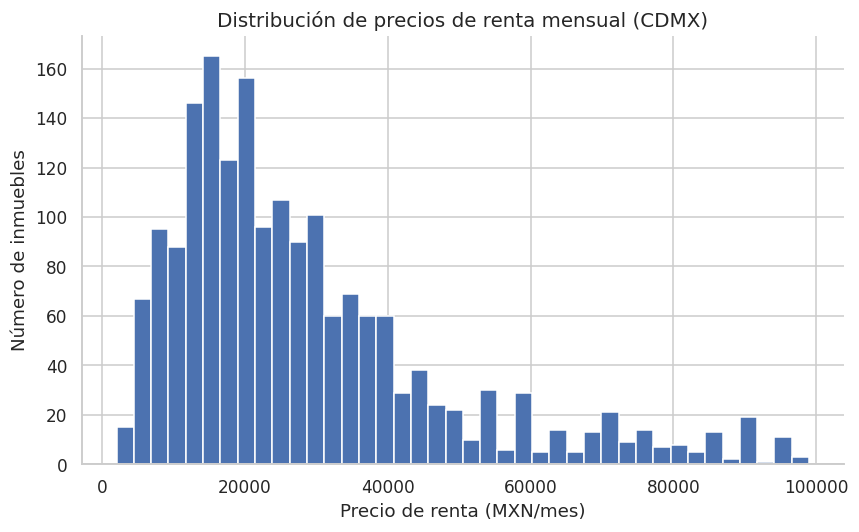

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
p99 = df["precio"].quantile(0.99)
ax.hist(df.loc[df["precio"] <= p99, "precio"], bins=40,
        color="#4c72b0", edgecolor="white")
ax.set_title("Distribución de precios de renta mensual (CDMX)")
ax.set_xlabel("Precio de renta (MXN/mes)")
ax.set_ylabel("Número de inmuebles")
ax.ticklabel_format(style="plain", axis="x")
fig.tight_layout()
fig.savefig("../figures/fig1_hist_precios.png", dpi=150)
plt.show()

### Figura 2 — Boxplot de precio por tipo de inmueble
Ordenamos los tipos por mediana ascendente para facilitar la lectura comparativa.

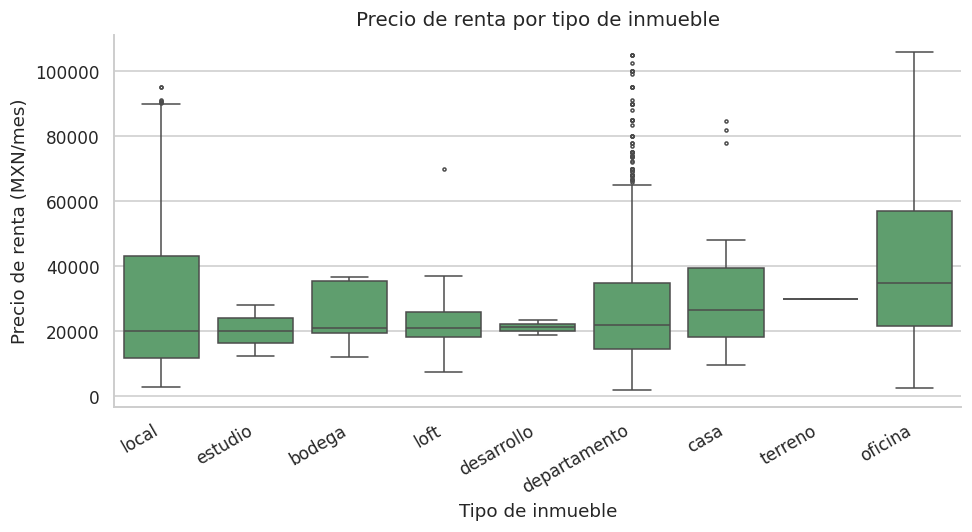

In [18]:
orden_tipo = df.groupby("tipo_inmueble")["precio"].median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="tipo_inmueble", y="precio", order=orden_tipo,
            ax=ax, color="#55a868", fliersize=2, linewidth=1)
ax.set_title("Precio de renta por tipo de inmueble")
ax.set_xlabel("Tipo de inmueble")
ax.set_ylabel("Precio de renta (MXN/mes)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
fig.savefig("../figures/fig2_box_precio_tipo.png", dpi=150)
plt.show()

### Figura 3 — Heatmap de correlaciones
Correlaciones de Pearson entre `precio`, `m2`, `recamaras` y `banos`.

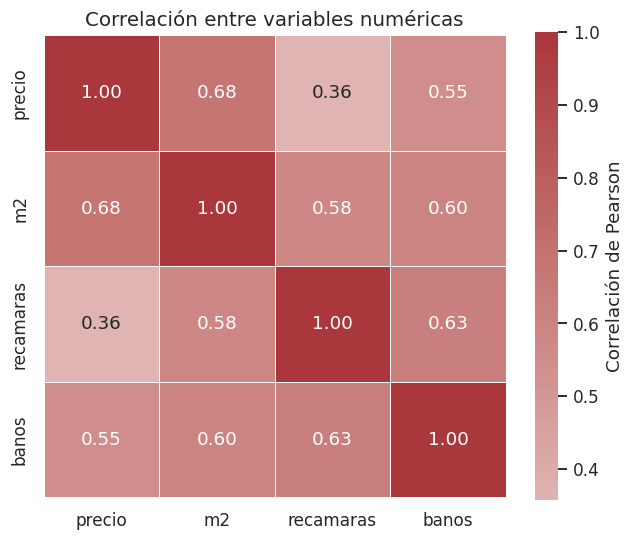

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[["precio", "m2", "recamaras", "banos"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Correlación de Pearson"})
ax.set_title("Correlación entre variables numéricas")
fig.tight_layout()
fig.savefig("../figures/fig3_heatmap_corr.png", dpi=150)
plt.show()

### Figura 4 — Top 10 alcaldías por precio por m²
Barras horizontales con la mediana de `precio_por_m2`; orientación horizontal para etiquetas legibles.

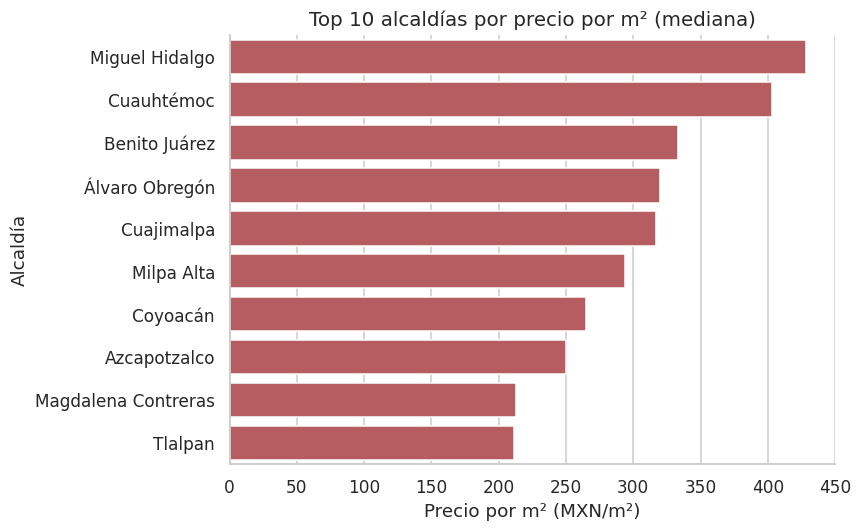

In [20]:
top10 = ranking_alcaldias.head(10).reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=top10, y="alcaldia", x="precio_por_m2", color="#c44e52", ax=ax)
ax.set_title("Top 10 alcaldías por precio por m² (mediana)")
ax.set_xlabel("Precio por m² (MXN/m²)")
ax.set_ylabel("Alcaldía")
fig.tight_layout()
fig.savefig("../figures/fig4_top10_alcaldias.png", dpi=150)
plt.show()

### Figura 5 — Dispersión precio vs m² con recta de regresión
`regplot` muestra la nube de puntos y la tendencia lineal ajustada.

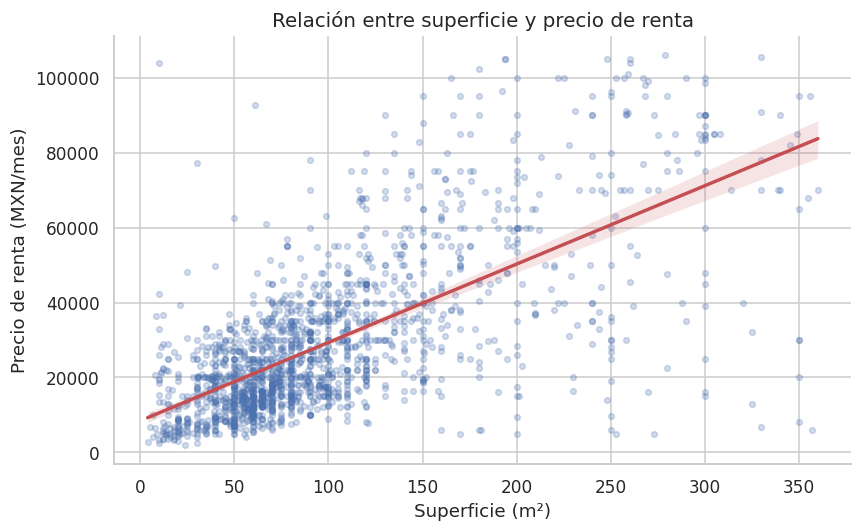

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x="m2", y="precio", ax=ax,
            scatter_kws={"alpha": 0.25, "s": 14, "color": "#4c72b0"},
            line_kws={"color": "#c44e52"})
ax.set_title("Relación entre superficie y precio de renta")
ax.set_xlabel("Superficie (m²)")
ax.set_ylabel("Precio de renta (MXN/mes)")
fig.tight_layout()
fig.savefig("../figures/fig5_scatter_precio_m2.png", dpi=150)
plt.show()

# Fase 5 — Conclusiones de negocio

### ¿En qué alcaldía conviene rentar (mejor relación precio/m²)?
Si el criterio es **minimizar el costo por metro cuadrado**, conviene rentar en las alcaldías al final del ranking (periféricas del oriente/sur), que ofrecen el m² más barato. En el otro extremo, **Miguel Hidalgo, Cuauhtémoc y Benito Juárez** son las **más caras por m²**: solo se justifican si se valora la **centralidad y las amenidades**. La decisión óptima depende del presupuesto y de cuánto se pondere la ubicación frente al espacio obtenido.

### ¿Algún tipo de inmueble parece subvalorado/sobrevalorado?
- **Oficinas y locales** muestran las rentas medianas más altas: están en el segmento *premium/comercial* (posible **sobrevaloración** para uso habitacional).
- **Departamentos** ofrecen la relación precio/m² más equilibrada y la oferta más amplia: el segmento más **eficiente** para el inquilino promedio.
- *Lofts* y *estudios* tienden a un precio por m² relativamente alto pese a su tamaño reducido, lo que puede leerse como **sobreprecio por ubicación/amenidad** en zonas céntricas.

### Hallazgos clave
1. La renta mediana en CDMX ronda los **\$22,000–26,500** mensuales tras filtrar anuncios de venta.
2. Superficie y precio están **moderada-fuertemente correlacionados** (Pearson ≈ 0.69): el tamaño importa, pero la ubicación pesa tanto como él.
3. Existe un claro **gradiente centro-periferia** en el precio por m².
4. El número de recámaras escala el precio de forma **monótona**.

### Limitaciones
- **Sesgo de portales:** MercadoLibre y Lamudi dominan la muestra; **Vivanuncios** quedó con ~19 filas por bloqueo de Cloudflare, y **Propiedades.com / Inmuebles24** se excluyeron por anti-bot.
- **Anuncios de venta filtrados:** se removieron precios de venta/errores mediante piso/techo de renta + IQR; cualquier residuo podría sesgar levemente las colas.
- **Cobertura desigual por alcaldía:** no todas las alcaldías tienen el mismo número de anuncios, por lo que medianas de zonas con poca oferta son menos confiables.
- El análisis es **observacional y transversal** (una sola captura temporal); no captura estacionalidad ni tendencias del mercado.
